| No. | Feature | Simple Meaning | What It Tells Us |
|---:|---|---|---|
| 1 | **Area** | Total area occupied by the bean in the image | Overall size of the bean |
| 2 | **Perimeter** | Length around the outer boundary of the bean | Boundary/outline size |
| 3 | **MajorAxisLength** | Length of the bean along its longest direction | How long the bean is |
| 4 | **MinorAxisLength** | Length across the bean's shortest direction | How wide the bean is |
| 5 | **AspectRation** | Ratio of major axis to minor axis | How elongated the bean is |
| 6 | **Eccentricity** | Measures how different the bean is from a circle | Round vs. elongated shape |
| 7 | **ConvexArea** | Area of the smallest convex shape covering the bean | Irregularity of the bean boundary |
| 8 | **EquivDiameter** | Diameter of a circle having the same area as the bean | Equivalent size in circular form |
| 9 | **Extent** | Ratio of bean area to its bounding-box area | How much of the surrounding box the bean fills |
| 10 | **Solidity** | Ratio of bean area to convex area | How solid/regular the bean shape is |
| 11 | **roundness** | Measures how close the bean is to a circle | Circularity of the bean |
| 12 | **Compactness** | Measures how compact the bean is based on its area and perimeter | Overall compactness |
| 13 | **ShapeFactor1** | Mathematical ratio derived from area, perimeter and axis dimensions | Fine shape characteristics |
| 14 | **ShapeFactor2** | Mathematical shape descriptor derived from bean geometry | Shape differences between bean types |
| 15 | **ShapeFactor3** | Another mathematical descriptor of bean shape | Shape/compactness characteristics |
| 16 | **ShapeFactor4** | Mathematical descriptor related to the bean's geometric shape | Fine boundary/shape differences |
| 17 | **Class** | Name/type of the bean | **Target variable for KNN classification** |


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('dry_bean_dataset.csv')


In [4]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [9]:
object_columns = df.select_dtypes(include=['object', 'bool']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)


Object type columns:
Index(['Class'], dtype='str')

Numerical type columns:
Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')


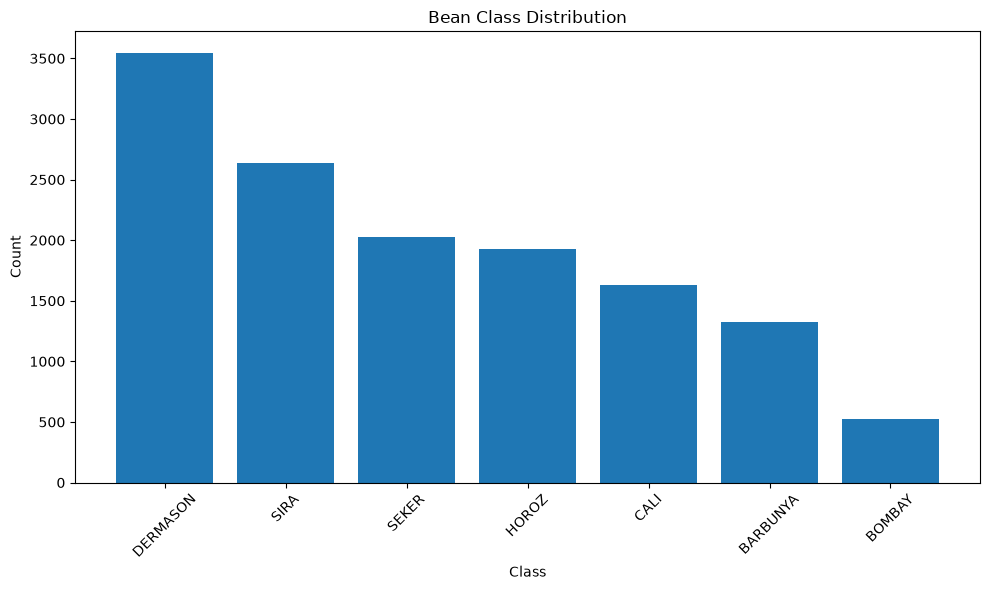

In [10]:
plt.figure(figsize=(10,6))
class_counts = df['Class'].value_counts()
plt.bar(class_counts.index, class_counts.values)
plt.title('Bean Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


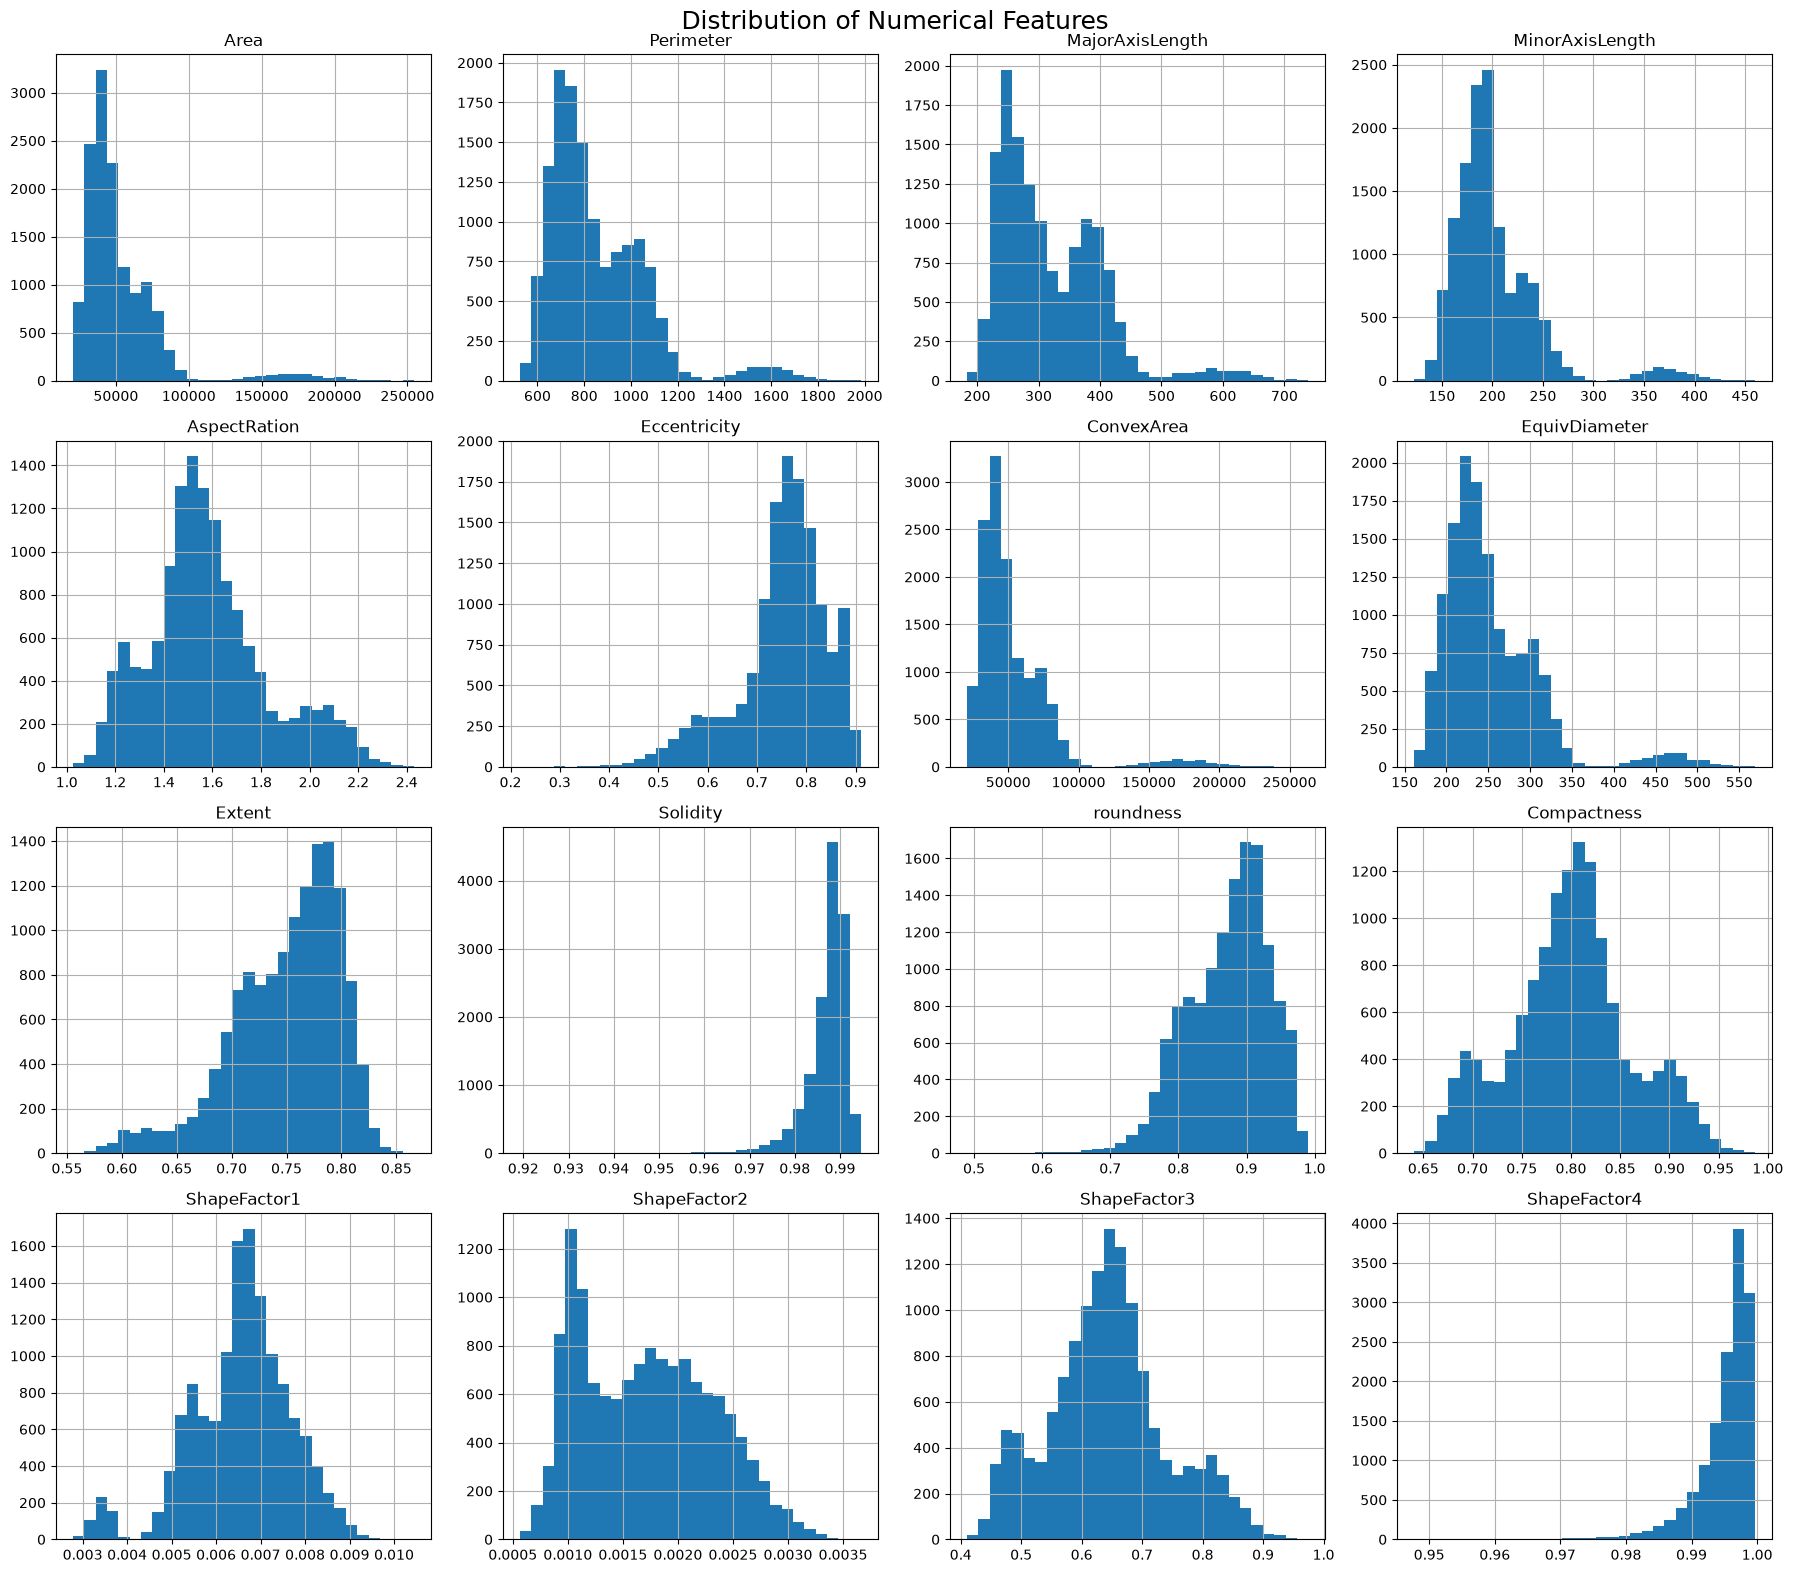

In [11]:
df.hist(figsize=(18,16), bins=30)
plt.suptitle('Distribution of Numerical Features', fontsize=18)
plt.tight_layout()
plt.show()


In [12]:
numerical_cols = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4']


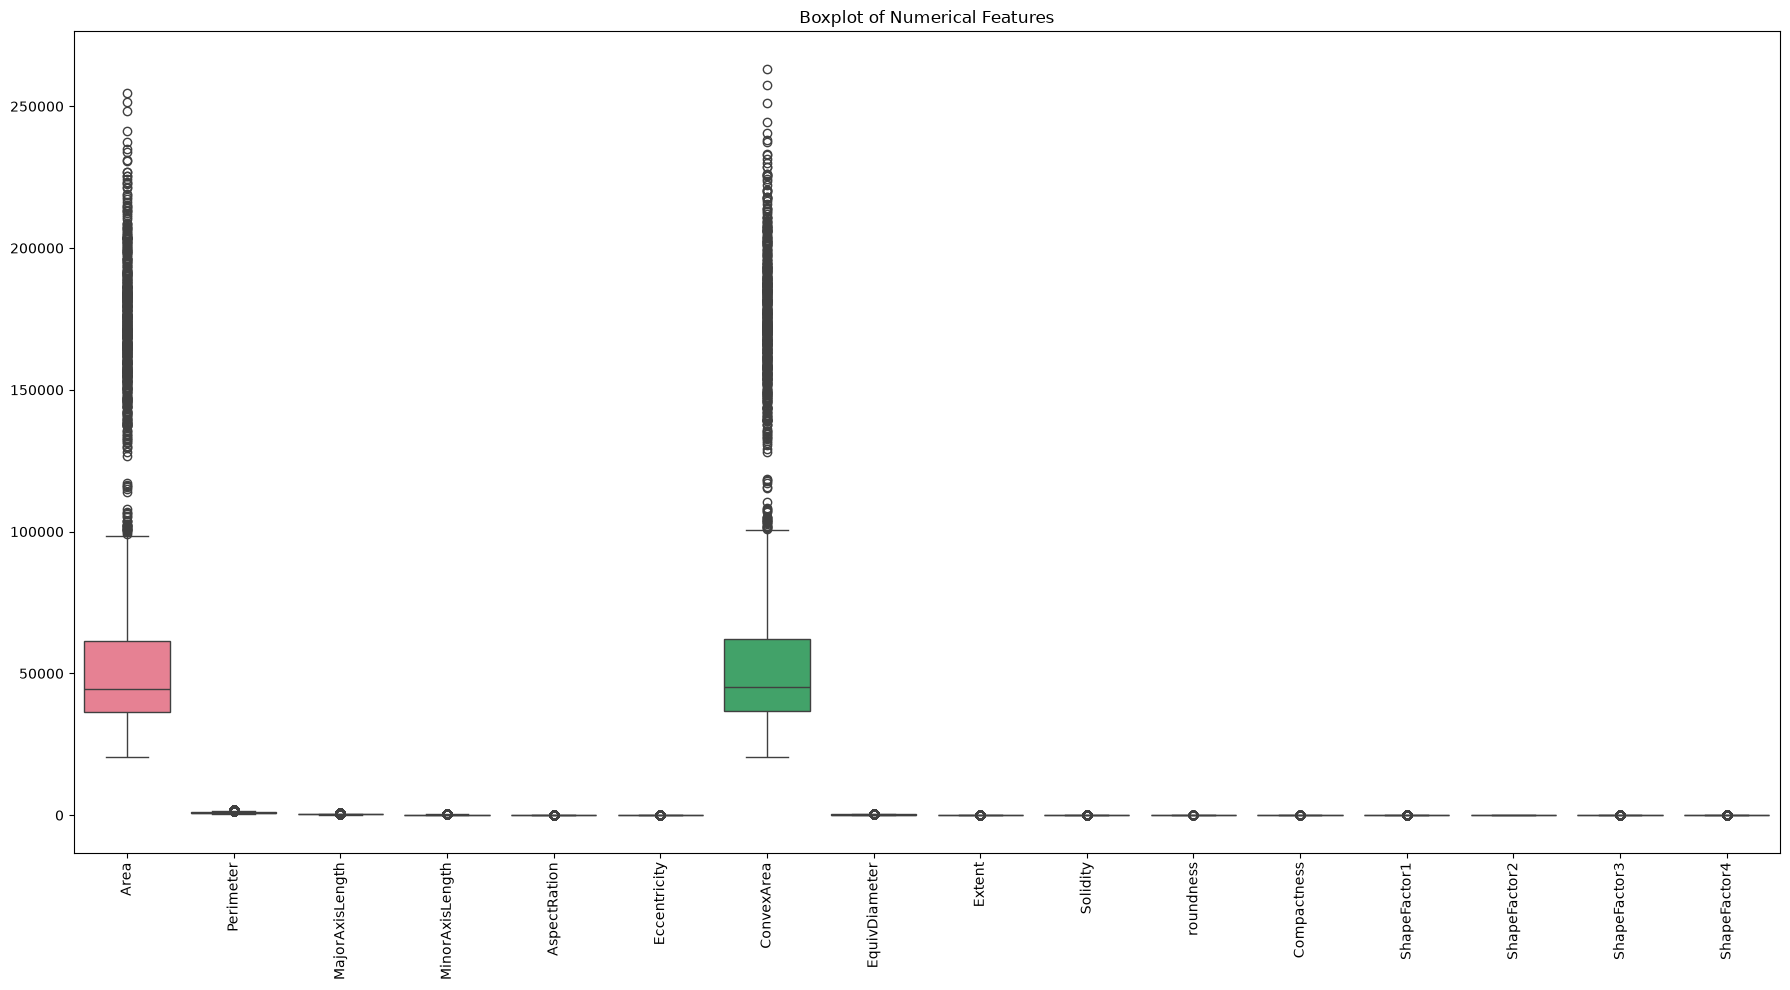

In [13]:
plt.figure(figsize=(18,10))
sns.boxplot(data=df[numerical_cols])
plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



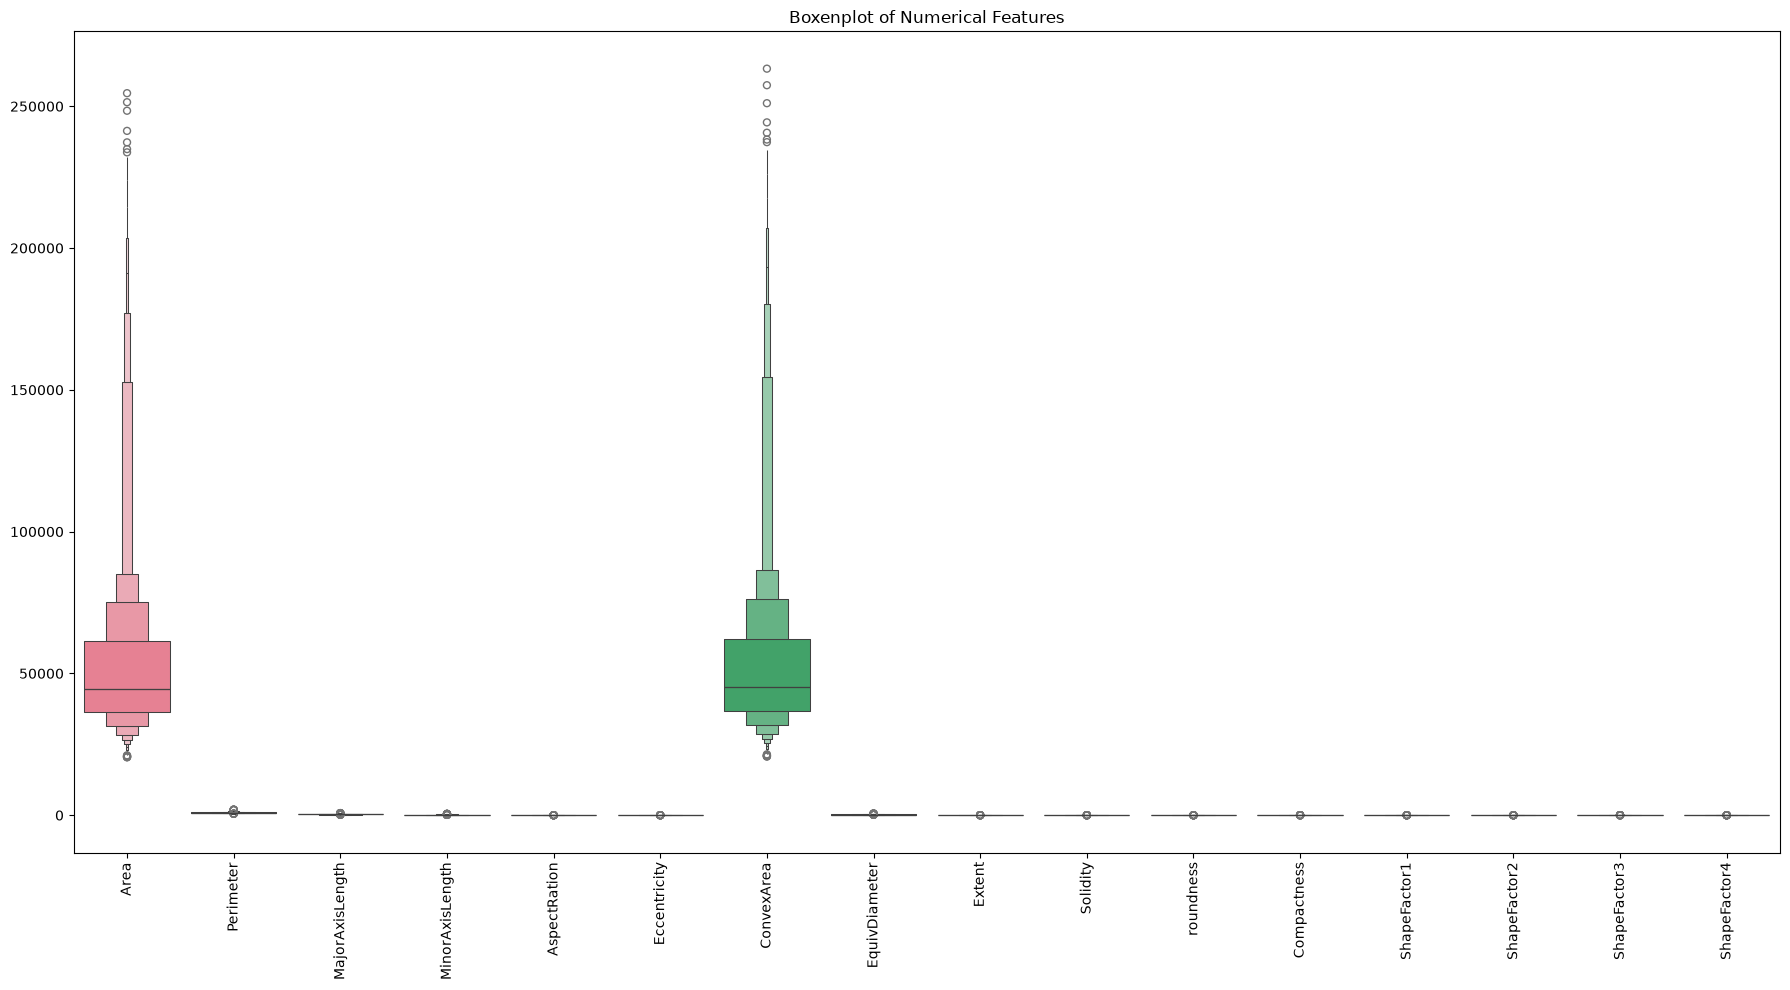

In [14]:
plt.figure(figsize=(18,10))
sns.boxenplot(data=df[numerical_cols])
plt.title('Boxenplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


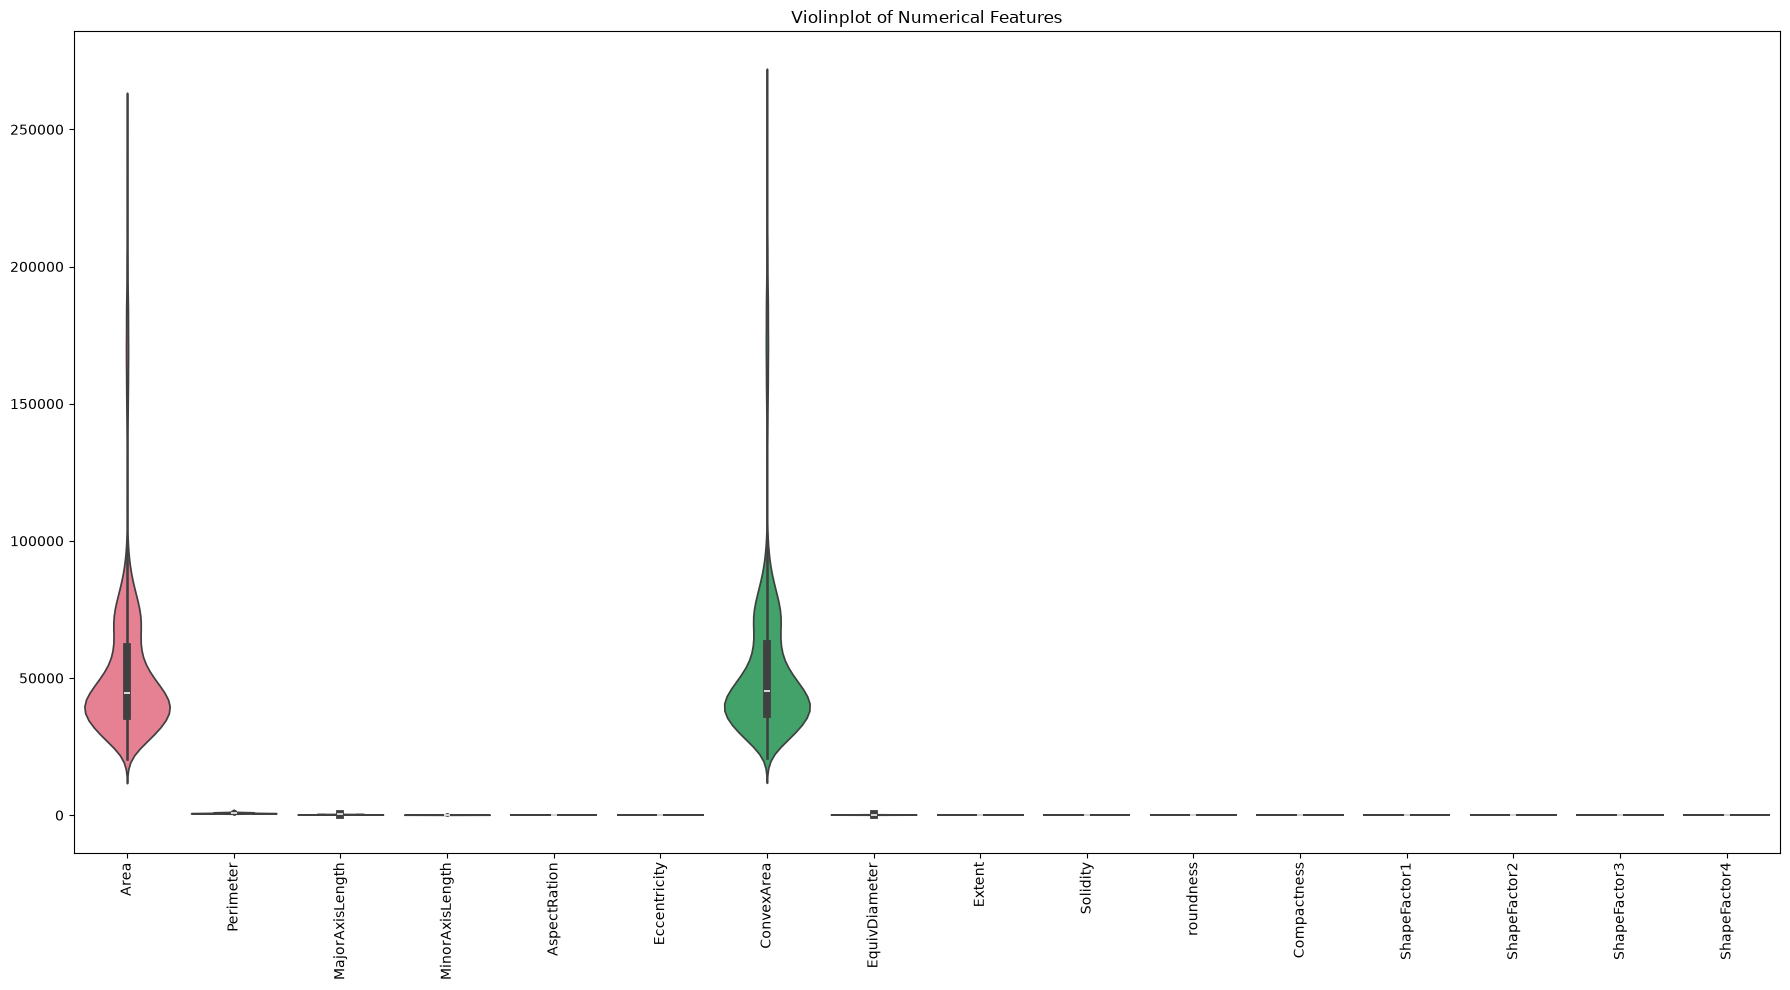

In [15]:
plt.figure(figsize=(18,10))
sns.violinplot(data=df[numerical_cols])
plt.title('Violinplot of Numerical Features')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

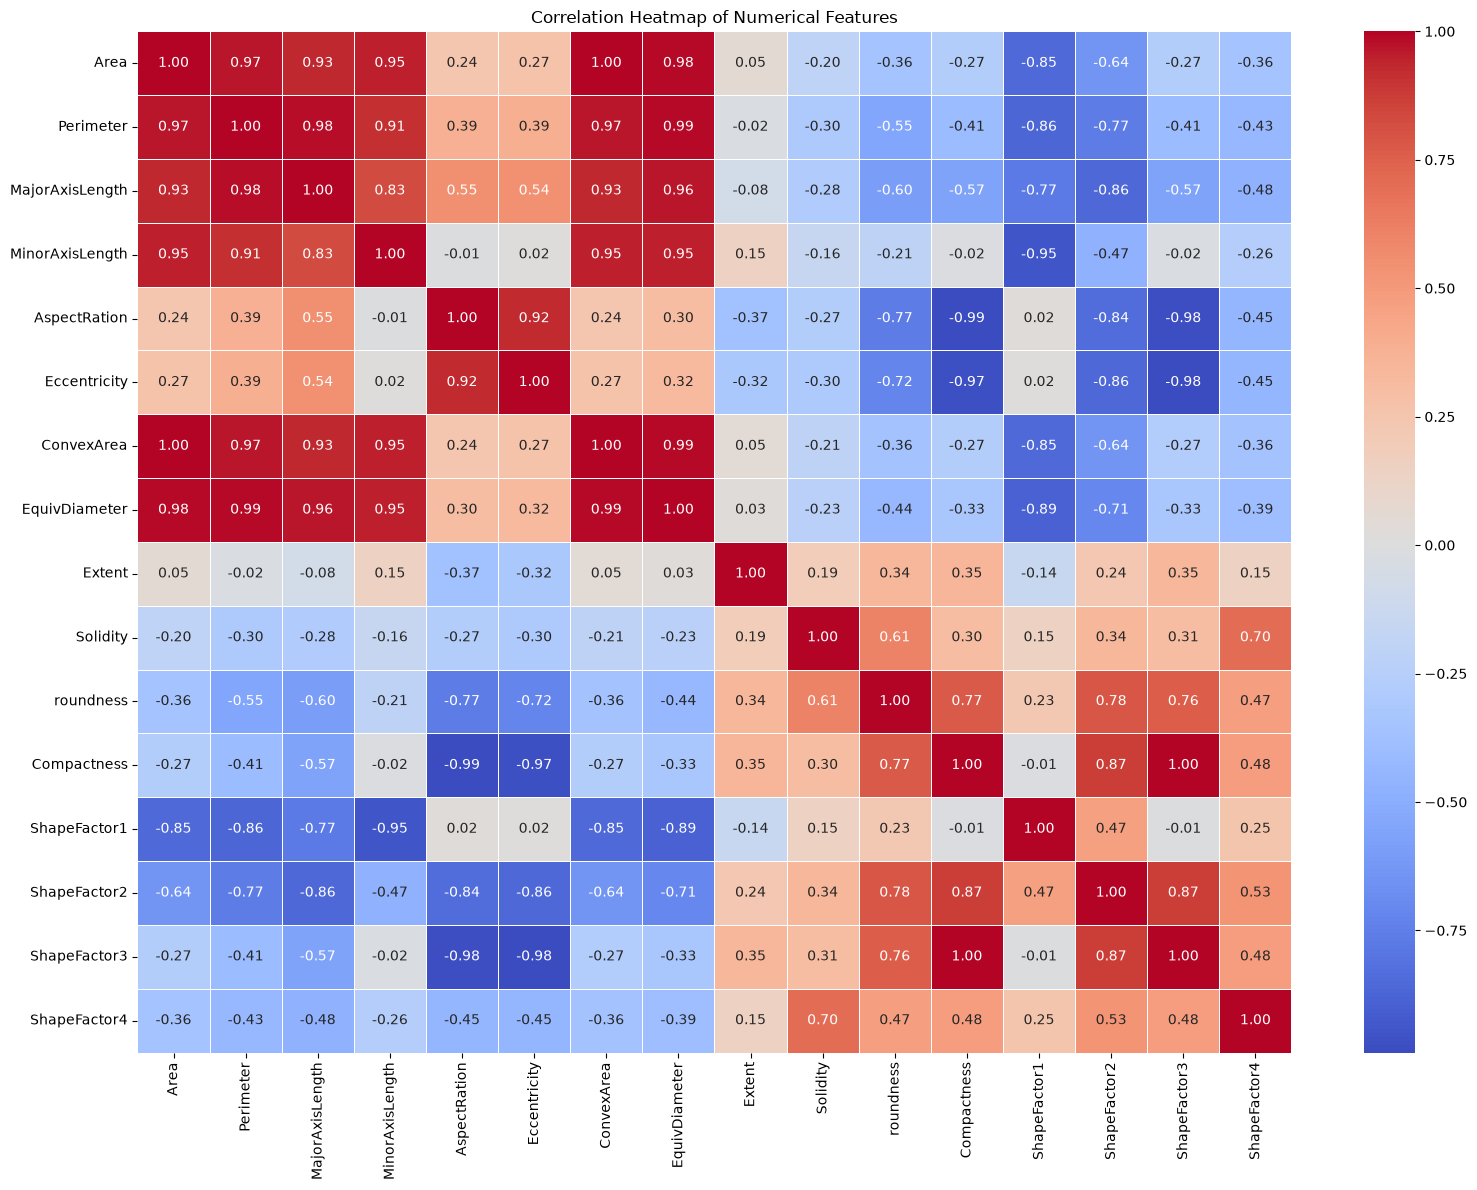

In [16]:
plt.figure(figsize=(16,12))
corr = df[numerical_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()